<a href="https://colab.research.google.com/github/sunkaravivek/ML-23CSE302/blob/main/lab-8/8.6_svm-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
data = pd.read_csv(
    '/content/SMSSpamCollection',
    sep='\t',
    header=None,
    names=['label', 'message']
)

print(data.head())
print(data.shape)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)


In [14]:
print(data['label'].unique())
print(data['label'].value_counts())

['ham' 'spam']
label
ham     4825
spam     747
Name: count, dtype: int64


In [15]:
data['label'] = data['label'].str.strip().str.lower()

data['label'] = data['label'].map({
    'ham': 0,
    'spam': 1
})

print(data['label'].unique())
print(data['label'].isnull().sum())

[0 1]
0


In [16]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(data['message'])
y = data['label']

print(X.shape)

(5572, 8713)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3900, 8713)
(1672, 8713)


In [18]:
model = SVC(kernel='linear')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)
print("Accuracy in Percentage:", int(accuracy * 100), "%")

Accuracy Score: 0.9880382775119617
Accuracy in Percentage: 98 %


In [21]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1447    1]
 [  19  205]]


In [24]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1448
           1       1.00      0.92      0.95       224

    accuracy                           0.99      1672
   macro avg       0.99      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



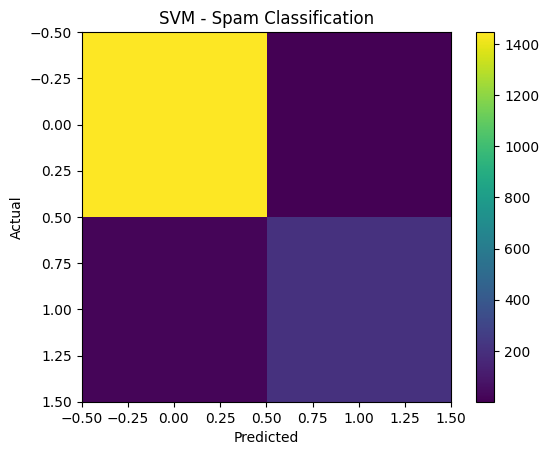

In [25]:
plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Spam Classification")

plt.colorbar()
plt.show()

In [26]:
new_message = ["Congratulations! You won a free prize. Click now!"]

new_message_features = vectorizer.transform(new_message)

prediction = model.predict(new_message_features)

if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Spam
